In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm.auto import tqdm

In [2]:
class Config:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    epochs = 5000
    batch_size = 256
    lr = 2e-4

    # Diffusion settings
    timesteps = 200
    beta_start = 1e-4
    beta_end = 0.02

    # Model settings
    data_dim = 11
    hidden_dim = 256

    # Sampling settings
    num_samples = 500

cfg = Config()
print(f"Using device: {cfg.device}")

Using device: cuda


In [3]:
# Diffusion schedule
betas = torch.linspace(cfg.beta_start, cfg.beta_end, cfg.timesteps, device=cfg.device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

def get_vals(x, t):
    """Get schedule scalar at vector t, return shape (B, 1)."""
    return x[t][:, None]

# Positional embedding and model
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor):
        half = self.dim // 2
        freqs = torch.exp(torch.arange(half, device=t.device) * -(math.log(10000) / max(1, (half - 1))))
        args = t[:, None].float() * freqs[None, :]
        embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
        return embedding

In [4]:
class DenoiseMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, time_emb_dim: int = 128, cond_dim: int = 1):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.Mish(),
            nn.Linear(time_emb_dim * 4, time_emb_dim),
        )
        self.net = nn.Sequential(
            nn.Linear(input_dim + time_emb_dim + cond_dim, hidden_dim),
            nn.Mish(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Mish(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x, t, condition):
        temb = self.time_mlp(t)
        xt = torch.cat([x, temb, condition], dim=-1)
        return self.net(xt)

In [5]:
# Generate and Prepare Data
# 1. Load the full 12-parameter dataset
full_data = np.load("doublet_data.npy").astype(np.float32)

# 2. Separate lens properties (X) from the performance condition (y)
X = full_data[:, :-1]  # First 11 columns are lens properties
y = full_data[:, -1:]   # Last column is the RMS spot size

# 3. Standardize the lens properties data (X)
mean = X.mean(axis=0)
std = X.std(axis=0)
X_scaled = (X - mean) / std

# 4. Create a DataLoader with both X and y
dataset = TensorDataset(torch.from_numpy(X_scaled), torch.from_numpy(y))
loader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True)

  0%|          | 0/5000 [00:00<?, ?it/s]


Training Finished!


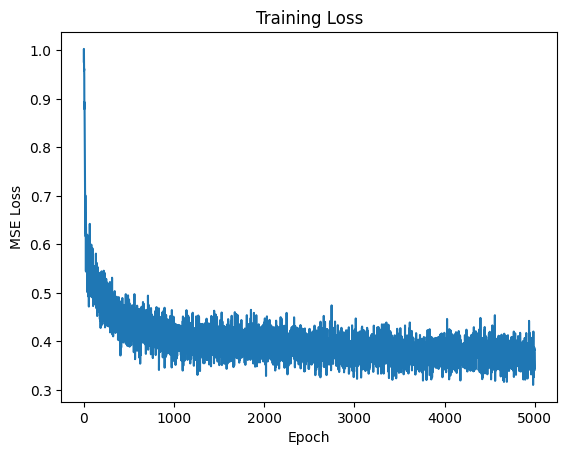

In [6]:
# Model and Optimizer
model = DenoiseMLP(input_dim=cfg.data_dim, hidden_dim=cfg.hidden_dim).to(cfg.device)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
loss_fn = nn.MSELoss()

# Forward process: q(x_t | x_0)
def q_sample(x0, t, noise):
    """Adds noise to the data x0 at timestep t."""
    sqrt_ac = get_vals(alphas_cumprod.sqrt(), t)
    sqrt_om_ac = get_vals((1.0 - alphas_cumprod).sqrt(), t)
    return sqrt_ac * x0 + sqrt_om_ac * noise

# Training Loop
losses = []
pbar = tqdm(range(cfg.epochs))

for epoch in pbar:
    # The loader now yields both the data (x0) and the condition (rms_condition)
    for x0, rms_condition in loader:
        x0 = x0.to(cfg.device)
        rms_condition = rms_condition.to(cfg.device) # Move condition to device
        B = x0.shape[0]

        # 1. Sample a random timestep
        t = torch.randint(0, cfg.timesteps, (B,), device=cfg.device)

        # 2. Add noise to the data (forward process)
        noise = torch.randn_like(x0)
        x_noisy = q_sample(x0, t, noise)
        
        # 3. Predict the noise, passing the condition to the model
        pred_noise = model(x_noisy, t, rms_condition)
        
        # 4. Calculate loss
        loss = loss_fn(pred_noise, noise)
        
        # 5. Backpropagate
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    losses.append(loss.item())
    pbar.set_description(f"Loss: {loss.item():.4f}")

print("\nTraining Finished!")
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

In [28]:
# Reverse process: p(x_{t-1} | x_t)
@torch.no_grad()
def p_sample_loop(num_samples: int, target_rms: float):
    """Generates new samples via the reverse diffusion process, conditioned on a target RMS."""
    model.eval()
    
    # Start with pure noise
    x = torch.randn(num_samples, cfg.data_dim, device=cfg.device)
    
    # Create the conditioning tensor with the target RMS value
    condition = torch.full((num_samples, 1), target_rms, device=cfg.device)
    
    for i in tqdm(reversed(range(cfg.timesteps)), total=cfg.timesteps, desc="Sampling"):
        t = torch.full((num_samples,), i, device=cfg.device)
        
        # Predict noise, passing the target condition to the model
        pred_noise = model(x, t, condition)
        
        # Get schedule constants
        alpha_t = alphas[i]
        alpha_cum_t = alphas_cumprod[i]
        
        # Denoising step formula
        coef1 = 1 / torch.sqrt(alpha_t)
        coef2 = (1 - alpha_t) / torch.sqrt(1 - alpha_cum_t)
        mean_pred = coef1 * (x - coef2 * pred_noise)

        if i > 0:
            noise = torch.randn_like(x)
            sigma = torch.sqrt(betas[i])
            x = mean_pred + sigma * noise
        else:
            x = mean_pred # No noise at the final step
            
    model.train()
    return x

# 1. Generate samples, providing a small target_rms for high performance!
target_performance = 0.001
print(f"Generating samples with a target RMS spot size of: {target_performance}")
samples_scaled = p_sample_loop(num_samples=cfg.num_samples, target_rms=target_performance).cpu().numpy()

# 2. Inverse scale to original data space
samples = samples_scaled * std + mean

Generating samples with a target RMS spot size of: 0.001


Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Displaying the first 3 generated lenses...

      GENERATED LENS #1
╒════╤═════════════════╤═══════════╤════════════╤═════════════╤═══════════════╤═════════╤═════════════════╕
│    │ Type            │ Comment   │     Radius │   Thickness │ Material      │   Conic │   Semi-aperture │
╞════╪═════════════════╪═══════════╪════════════╪═════════════╪═══════════════╪═════════╪═════════════════╡
│  0 │ Planar          │           │ inf        │  inf        │ Air           │       0 │     0.078643    │
│  1 │ Stop - Standard │           │  85.204    │    0.102268 │ 1.5575, 54.55 │       0 │     0.078643    │
│  2 │ Standard        │           │   8.05014  │    0.102121 │ 1.5803, 44.39 │       0 │     0.0786091   │
│  3 │ Standard        │           │  -0.598373 │    1.01683  │ Air           │       0 │     0.0785611   │
│  4 │ Planar          │           │ inf        │  nan        │ Air           │       0 │     1.38778e-17 │
╘════╧═════════════════╧═══════════╧════════════╧═════════════╧═════

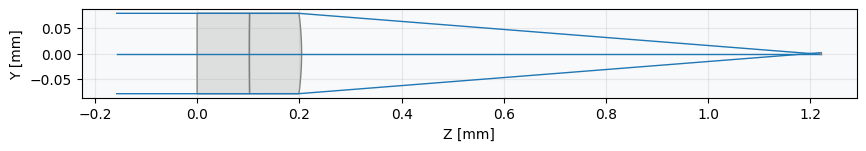

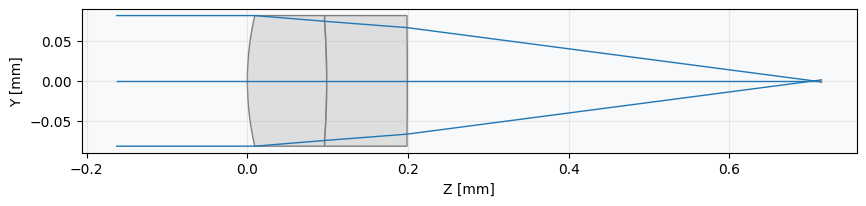

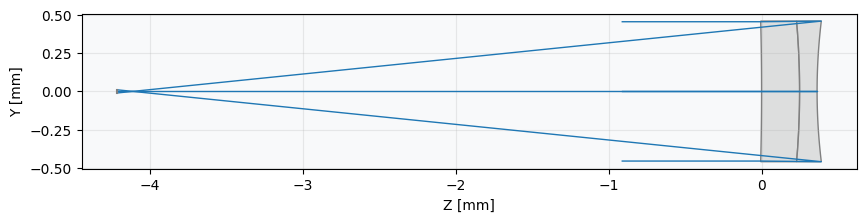

In [ ]:
from optiland import optic, materials

class GeneratedDoublet(optic.Optic):
    """
    Constructs a doublet lens system from a predefined 11-parameter vector.
    
    The parameter vector should be in the order:
    [r0, r1, r2, t0, t1, t2, n0, v0, n1, v1, f_number]
    """
    def __init__(self, properties: np.ndarray):
        super().__init__()
        
        # Unpack the 11 properties from the input vector
        r0, r1, r2, t0, t1, t2, n0, v0, n1, v1, f_number = properties
        
        # Create glass materials from refractive index (n) and Abbe number (v)
        mat0 = materials.AbbeMaterial(n=n0, abbe=v0)
        mat1 = materials.AbbeMaterial(n=n1, abbe=v1)
        
        # Build the optical system
        # Surface 0: Object plane (at infinity)
        self.add_surface(index=0, radius=np.inf, thickness=np.inf)
        # Surface 1: Front surface of the first element (also the stop)
        self.add_surface(index=1, thickness=t0, radius=r0, is_stop=True, material=mat0)
        # Surface 2: Back surface of the first element / Front of the second
        self.add_surface(index=2, thickness=t1, radius=r1, material=mat1)
        # Surface 3: Back surface of the second element
        self.add_surface(index=3, thickness=t2, radius=r2)
        # Surface 4: Image plane
        self.add_surface(index=4)
        
        # Set the system's aperture using the f-number
        self.set_aperture(aperture_type='imageFNO', value=f_number)
        
        # Set a default on-axis field of view
        self.set_field_type(field_type='angle')
        self.add_field(y=0.0)
        
        # Set the primary wavelength for analysis (e.g., 550nm)
        self.add_wavelength(value=0.55, is_primary=True)

# Loop through the generated samples and display them
num_to_show = 3
print(f"Displaying the first {num_to_show} generated lenses...\n")

for i in range(num_to_show):
    # Select the i-th design from the generated samples
    design_properties = samples[i]
    
    # Create the lens object
    lens = GeneratedDoublet(properties=design_properties)

    lens.image_solve()
    
    print("===================================")
    print(f"      GENERATED LENS #{i+1}")
    print("===================================")
    
    # Print the system's paraxial properties and surface data
    lens.info()
    
    # Draw the lens layout
    lens.draw()